# import libraries


In [639]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Pre processing

In [640]:
df = pd.read_csv("penguins.csv")
df

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,Torgersen,3750.0
1,Adelie,39.5,17.4,186.0,Torgersen,3800.0
2,Adelie,40.3,18.0,195.0,Torgersen,3250.0
3,Adelie,NaN,NaN,NaN,Torgersen,NaN
4,Adelie,36.7,19.3,193.0,Torgersen,3450.0
...,...,...,...,...,...,...
145,Gentoo,NaN,NaN,NaN,Biscoe,NaN
146,Gentoo,46.8,14.3,215.0,Biscoe,4850.0
147,Gentoo,50.4,15.7,222.0,Biscoe,5750.0
148,Gentoo,45.2,14.8,212.0,Biscoe,5200.0


In [641]:
df.head()

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,Torgersen,3750.0
1,Adelie,39.5,17.4,186.0,Torgersen,3800.0
2,Adelie,40.3,18.0,195.0,Torgersen,3250.0
3,Adelie,NaN,NaN,NaN,Torgersen,NaN
4,Adelie,36.7,19.3,193.0,Torgersen,3450.0


In [642]:
df.tail()

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
145,Gentoo,NaN,NaN,NaN,Biscoe,NaN
146,Gentoo,46.8,14.3,215.0,Biscoe,4850.0
147,Gentoo,50.4,15.7,222.0,Biscoe,5750.0
148,Gentoo,45.2,14.8,212.0,Biscoe,5200.0
149,Gentoo,49.9,16.1,213.0,Biscoe,5400.0


In [643]:
df.shape

(150, 6)

In [644]:
df.duplicated().sum()

np.int64(0)

In [645]:
df.isnull().sum()

Species           0
CulmenLength      2
CulmenDepth       2
FlipperLength     2
OriginLocation    0
BodyMass          2
dtype: int64

In [646]:
df.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass
count,148.000000,148.000000,148.000000,148.000000
mean,45.089865,17.377703,199.277027,4186.486486
std,5.385578,2.072129,14.160797,817.476925
min,34.100000,13.100000,172.000000,2700.000000
25%,40.500000,15.700000,187.750000,3550.000000
50%,46.100000,17.800000,196.000000,3950.000000
75%,49.350000,18.900000,212.250000,4681.250000
max,59.600000,21.500000,230.000000,6300.000000


In [647]:
df.columns

Index(['Species', 'CulmenLength', 'CulmenDepth', 'FlipperLength',
       'OriginLocation', 'BodyMass'],
      dtype='object')

In [648]:
num_col = ['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass']

In [649]:
for i in num_col:
 mask = (df["Species"] == "Adelie") & (df["OriginLocation"] == "Torgersen")
 mean_fill = df.loc[mask, i].mean()
 df.loc[mask, i] = df.loc[mask, i].fillna(mean_fill).round(1)
  


In [650]:
df.head(10)

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,Torgersen,3750.0
1,Adelie,39.5,17.4,186.0,Torgersen,3800.0
2,Adelie,40.3,18.0,195.0,Torgersen,3250.0
3,Adelie,38.8,19.0,189.3,Torgersen,3763.2
4,Adelie,36.7,19.3,193.0,Torgersen,3450.0
5,Adelie,39.3,20.6,190.0,Torgersen,3650.0
6,Adelie,38.9,17.8,181.0,Torgersen,3625.0
7,Adelie,39.2,19.6,195.0,Torgersen,4675.0
8,Adelie,34.1,18.1,193.0,Torgersen,3475.0
9,Adelie,42.0,20.2,190.0,Torgersen,4250.0


In [651]:
for i in num_col:
 mask = (df["Species"] == "Gentoo") & (df["OriginLocation"] == "Biscoe")
 mean_fill = df.loc[mask, i].mean()
 df.loc[mask, i] = df.loc[mask, i].fillna(mean_fill).round(1)

In [652]:
df.isnull().sum()

Species           0
CulmenLength      0
CulmenDepth       0
FlipperLength     0
OriginLocation    0
BodyMass          0
dtype: int64

In [653]:
df["OriginLocation"].value_counts()

OriginLocation
Dream        70
Biscoe       60
Torgersen    20
Name: count, dtype: int64

In [654]:

origin_location = {"Dream" : 1, "Biscoe" : 2, "Torgersen" : 3}
df["OriginLocation"]=df["OriginLocation"].map(origin_location)

In [655]:
df

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,3,3750.0
1,Adelie,39.5,17.4,186.0,3,3800.0
2,Adelie,40.3,18.0,195.0,3,3250.0
3,Adelie,38.8,19.0,189.3,3,3763.2
4,Adelie,36.7,19.3,193.0,3,3450.0
...,...,...,...,...,...,...
145,Gentoo,47.5,14.9,216.4,2,5128.1
146,Gentoo,46.8,14.3,215.0,2,4850.0
147,Gentoo,50.4,15.7,222.0,2,5750.0
148,Gentoo,45.2,14.8,212.0,2,5200.0


In [656]:
df["Species"].value_counts()

Species
Adelie       50
Chinstrap    50
Gentoo       50
Name: count, dtype: int64

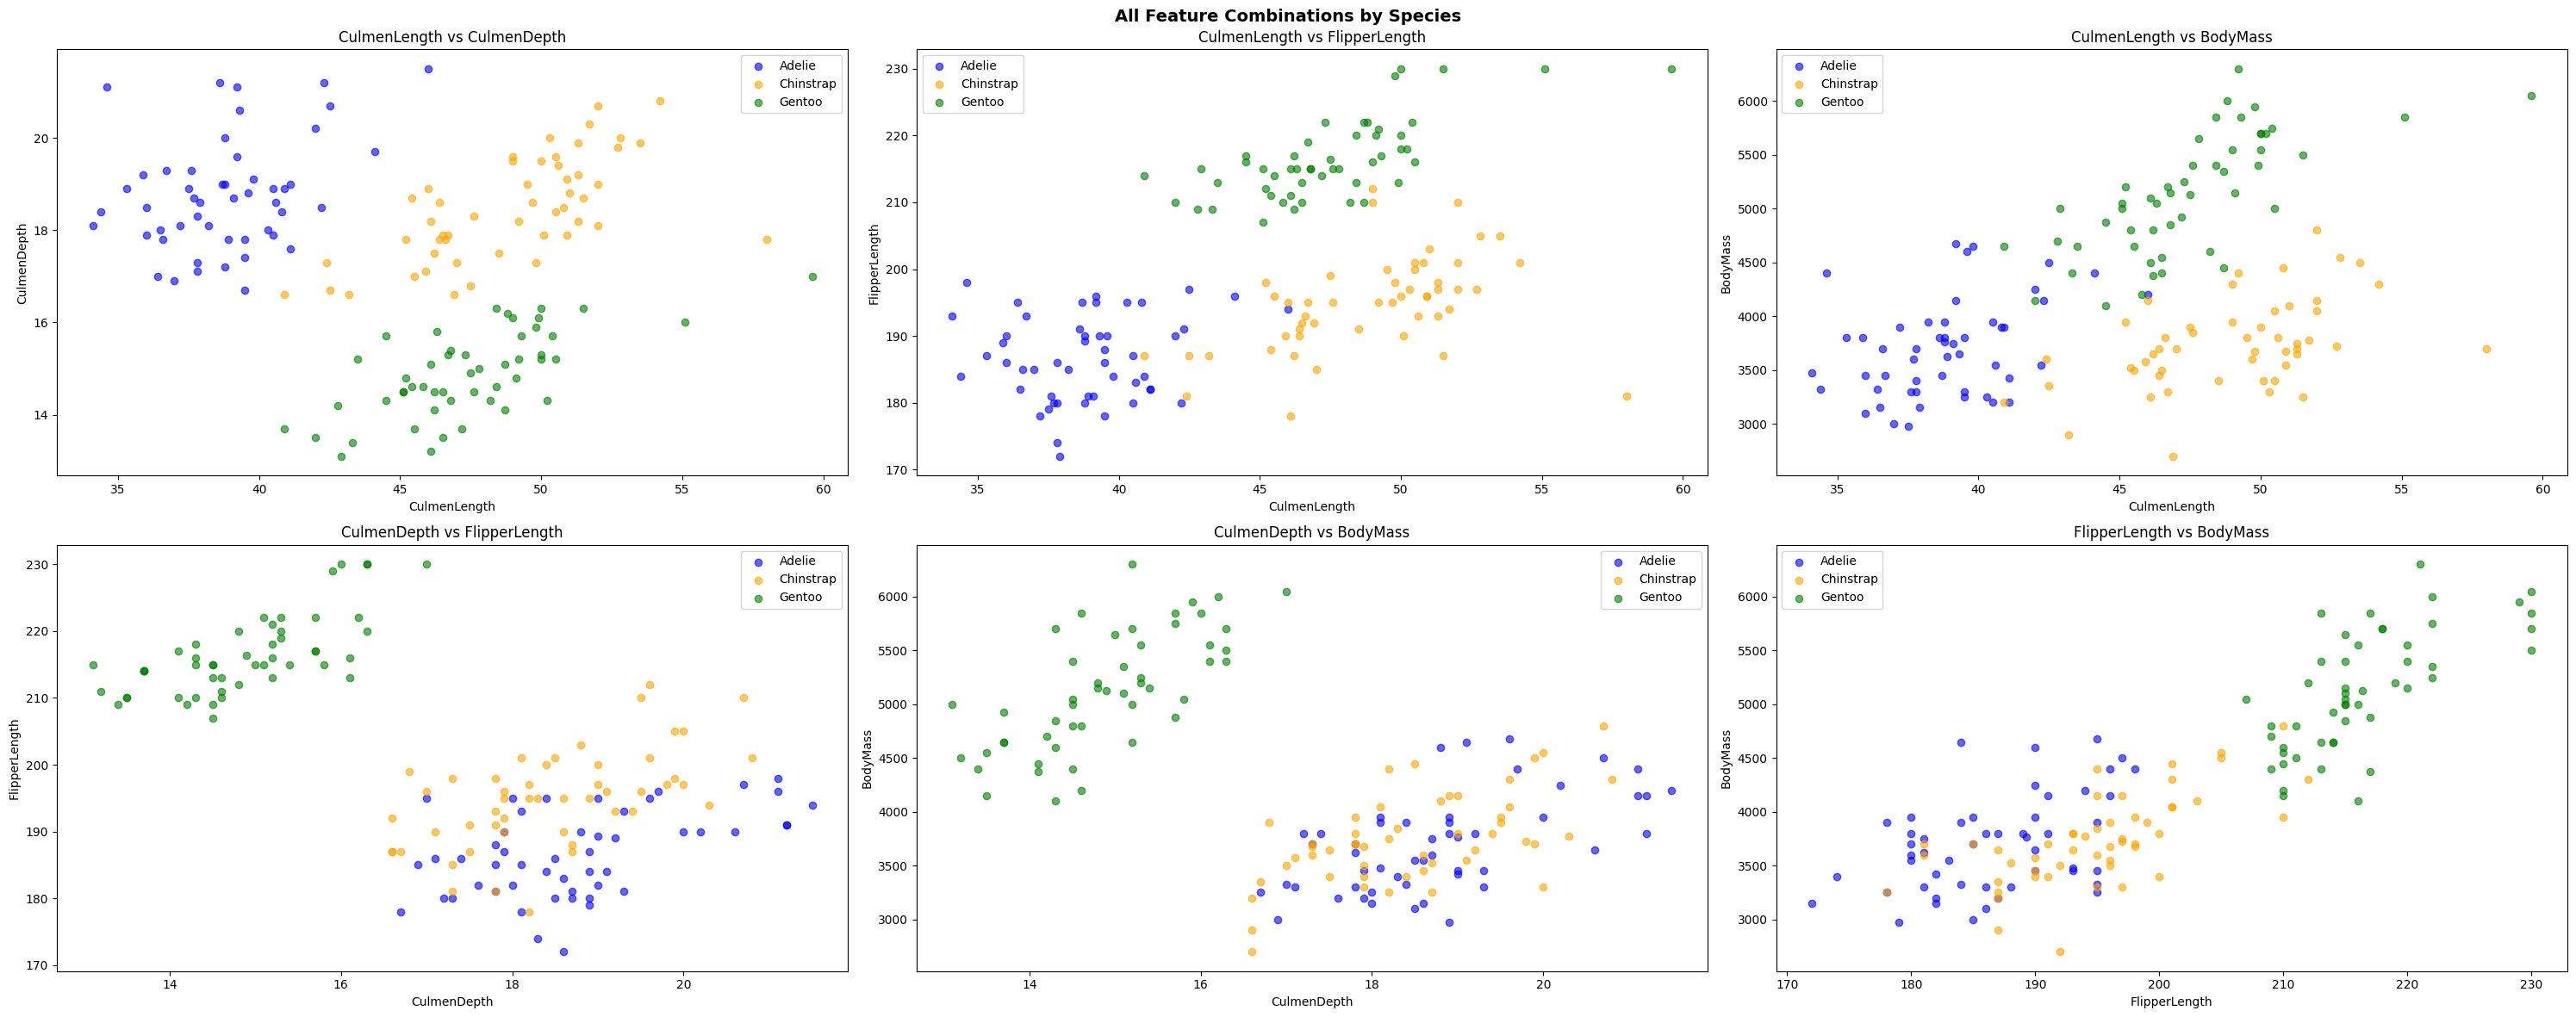

In [657]:
from itertools import combinations

features = ["CulmenLength", "CulmenDepth", "FlipperLength", "BodyMass"]
combos = list(combinations(features, 2))  

colors = {"Adelie": "blue", "Chinstrap": "orange", "Gentoo": "green"}

fig, axes = plt.subplots(2, 3, figsize=(30, 12))
axes = axes.flatten()

for i, (feat1, feat2) in enumerate(combos):
    ax = axes[i]
    for species, color in colors.items():
        subset = df[df["Species"] == species]
        ax.scatter(subset[feat1], subset[feat2], label=species, color=color, alpha=0.6)
    
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    ax.set_title(f"{feat1} vs {feat2}")
    ax.legend()


plt.suptitle("All Feature Combinations by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("penguin_all_combinations.png", dpi=150)
plt.show()

# Splitting data

In [658]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.4,
    stratify=df["Species"],
    random_state=42
)

In [659]:
train_df["Species"].value_counts()

Species
Gentoo       30
Adelie       30
Chinstrap    30
Name: count, dtype: int64

In [660]:
test_df['Species'].value_counts()

Species
Adelie       20
Chinstrap    20
Gentoo       20
Name: count, dtype: int64

In [661]:
def signum(x):
    if x >= 0:
        return 1
    else:
        return -1

In [662]:
train_df_1 = train_df[train_df["Species"].isin(["Adelie", "Gentoo"])]
train_df_1.count
x = train_df_1.drop(columns="Species")
y = train_df_1["Species"]

In [663]:
test_df_1 = test_df[test_df["Species"].isin(["Adelie", "Gentoo"])]
test_df_1.count()
x_test = test_df_1.drop(columns="Species")
y_test = test_df_1["Species"]


In [664]:
y = y.map({"Adelie":1, "Gentoo":-1})

In [665]:
y_test = y_test.map({"Adelie":1, "Gentoo":-1})

In [666]:
y_test.value_counts()

Species
 1    20
-1    20
Name: count, dtype: int64

# Perception train and test functions

In [667]:
w0 = np.random.rand()
w1 = np.random.rand()
print(w1)
w2 = np.random.rand()
bias = 0

def perceptron_train(x, y,w0,w1,w2, lr=0.0001, epochs=200):

    for _ in range(epochs):

        for x1, x2, target in zip(x["CulmenLength"], x["CulmenDepth"], y):

            net = w1*x1 + w2*x2 + w0*bias
            # activation
            y_pred= signum(net)
        
            # update rule
            if y_pred != target:
                error = target - y_pred
                w1 = w1 + lr * error * x1
                w2 = w2 + lr * error * x2
                w0 = w0 + lr * error

    return w1,w2,w0
w1, w2, w0 = perceptron_train(x,y , w0, w1, w2, lr=0.01, epochs=100)

print("Updated weights:", w0, w1, w2)



0.47013375079830255
Updated weights: 0.9772351167806814 -0.2798662492016972 0.7286561270062755


In [668]:
def perceptron_test(x_test, y_test, w0, w1, w2):
    predictions = []
    correct_count = 0
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for x1, x2, target in zip(x_test["CulmenLength"], x_test["CulmenDepth"], y_test):
        net = w1 * x1 + w2 * x2 + w0 * bias
        pred = signum(net)
        predictions.append(pred)
        
        
        if pred == 1 and target == 1:
            TP += 1

        elif pred == -1 and target == -1:
            TN += 1

        elif pred == 1 and target == -1:
            FP += 1

        elif pred == -1 and target == 1:
            FN += 1

    print("Confusion Matrix")
    print([[TP, FP],
           [FN, TN]])
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    return predictions,accuracy
    
preds, acc = perceptron_test(x_test, y_test, w0, w1, w2)
print("Predictions:", preds)
print("Accuracy:", acc)

        

        

Confusion Matrix
[[20, 0], [0, 20]]
Predictions: [1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1]
Accuracy: 1.0


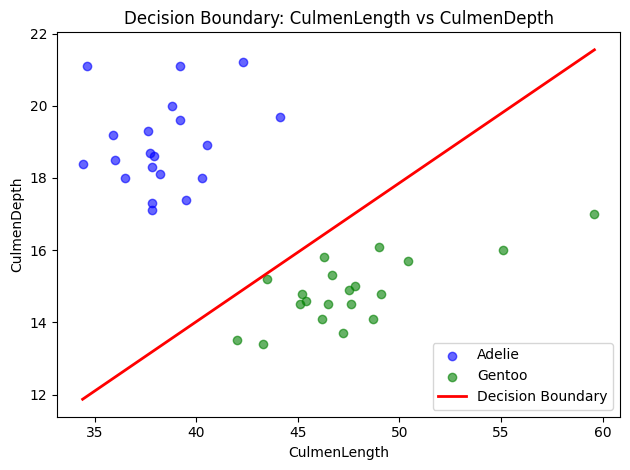

In [669]:
def plot_decision_boundary(x_test, y_test, w0, w1, w2, feat1="CulmenLength", feat2="CulmenDepth"):
    
    colors = {1: "blue", -1: "green"}
    labels = {1: "Adelie", -1: "Gentoo"}

    for target, color in colors.items():
        mask = y_test == target
        plt.scatter(x_test.loc[mask, feat1], x_test.loc[mask, feat2],
                    color=color, label=labels[target], alpha=0.6)

    # W1*x1 + W2*x2 + B = 0  =>  x2 = -(W1*x1 + B) / W2
    x1_vals = np.linspace(x_test[feat1].min(), x_test[feat1].max(), 100)
    x2_vals = -(w1 * x1_vals + w0) / w2

    plt.plot(x1_vals, x2_vals, color="red", linewidth=2, label="Decision Boundary")

    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f"Decision Boundary: {feat1} vs {feat2}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_boundary(x_test, y_test, w0, w1, w2)


# Adaline train and test function

In [670]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale train and test using only train fit
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns, index=x.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

# Reset weights before training
w0, w1, w2 = np.random.rand(), np.random.rand(), np.random.rand()

def adaline_train(x, y, w0, w1, w2, lr=0.0001, epochs=1000, mse_threshold=0.01):
    for _ in range(epochs):
        total_error = 0

        for x1, x2, target in zip(x["CulmenLength"], x["CulmenDepth"], y):
            net = w1*x1 + w2*x2 + w0*bias

            error = target - net
            w1 = w1 + lr * error * x1
            w2 = w2 + lr * error * x2
            w0 = w0 + lr * error
            total_error += pow(error, 2)

        mse = total_error / len(y)
        if mse < mse_threshold:
            break

    return w1, w2, w0, mse

# Now pass x_scaled consistently
w1, w2, w0, mse = adaline_train(x_scaled, y, w0, w1, w2, lr=0.0001, epochs=1000, mse_threshold=0.01)
print("MSE score:", mse)

MSE score: 0.07362912673712696


In [671]:
def adaline_test(x_test, y_test, w0, w1, w2):
    predictions = []
    correct_count = 0
    
    for x1, x2, target in zip(x_test["CulmenLength"], x_test["CulmenDepth"], y_test):
        net = w1 * x1 + w2 * x2 + w0 * bias
        pred = signum(net)
        predictions.append(pred)
        
        if pred == target:
            correct_count += 1
    
    accuracy = correct_count / len(y_test)
    return predictions, accuracy

preds, acc = adaline_test(x_test_scaled, y_test, w0, w1, w2)
print("Predictions:", preds)
print("Accuracy:", acc)

Predictions: [1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1]
Accuracy: 1.0
